# Chicago Crime Data Analysis


## 1. Introduction

This project analyzes crime patterns in Chicago using Python.  
The goal is to identify trends based on crime type, time, and day.

Tools used: pandas, matplotlib

In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/cleaned/crime_data.csv")
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13709672,JJ101940,12/31/2024 11:58:00 PM,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,5,43.0,14,1186817.0,1860189.0,2024,11/02/2025 03:41:09 PM,41.771470,-87.590742,POINT (-87.59074212 41.771470188)
1,13707925,JJ100089,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,...,3,38.0,26,1179661.0,1873623.0,2024,05/17/2025 03:40:52 PM,41.808501,-87.616563,POINT (-87.616562762 41.808500903)
2,13708038,JJ100035,12/31/2024 11:55:00 PM,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,...,18,70.0,04B,1145740.0,1853048.0,2024,11/02/2025 03:41:09 PM,41.752749,-87.741498,POINT (-87.741497836 41.752748627)
3,13709164,JJ101392,12/31/2024 11:53:00 PM,066XX S GREENWOOD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,20,42.0,14,1184362.0,1861188.0,2024,11/02/2025 03:41:09 PM,41.774269,-87.599710,POINT (-87.599709962 41.774269351)
4,13707823,JJ100020,12/31/2024 11:50:00 PM,012XX N MENARD AVE,0460,BATTERY,SIMPLE,SIDEWALK,False,False,...,29,25.0,08B,1137458.0,1907694.0,2024,05/17/2025 03:40:52 PM,41.902858,-87.770537,POINT (-87.770536741 41.902858242)


In [3]:
df.shape

(259037, 22)

In [4]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259037 entries, 0 to 259036
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    259037 non-null  int64  
 1   Case Number           259037 non-null  object 
 2   Date                  259037 non-null  object 
 3   Block                 259037 non-null  object 
 4   IUCR                  259037 non-null  object 
 5   Primary Type          259037 non-null  object 
 6   Description           259037 non-null  object 
 7   Location Description  257913 non-null  object 
 8   Arrest                259037 non-null  bool   
 9   Domestic              259037 non-null  bool   
 10  Beat                  259037 non-null  int64  
 11  District              259037 non-null  int64  
 12  Ward                  259037 non-null  int64  
 13  Community Area        259030 non-null  float64
 14  FBI Code              259037 non-null  object 
 15  

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

/var/folders/9s/f64mf5h91k7_zhfz27k5_c600000gn/T/ipykernel_26711/2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259037 entries, 0 to 259036
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    259037 non-null  int64         
 1   Case Number           259037 non-null  object        
 2   Date                  259037 non-null  datetime64[ns]
 3   Block                 259037 non-null  object        
 4   IUCR                  259037 non-null  object        
 5   Primary Type          259037 non-null  object        
 6   Description           259037 non-null  object        
 7   Location Description  257913 non-null  object        
 8   Arrest                259037 non-null  bool          
 9   Domestic              259037 non-null  bool          
 10  Beat                  259037 non-null  int64         
 11  District              259037 non-null  int64         
 12  Ward                  259037 non-null  int64         
 13 

In [8]:
df.isnull().sum()

ID                         0
Case Number                0
Date                       0
Block                      0
IUCR                       0
Primary Type               0
Description                0
Location Description    1124
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                       0
Community Area             7
FBI Code                   0
X Coordinate            1493
Y Coordinate            1493
Year                       0
Updated On                 0
Latitude                1493
Longitude               1493
Location                1493
dtype: int64

In [10]:
df.isnull().sum().sort_values(ascending=False)

Location                1493
Longitude               1493
Latitude                1493
Y Coordinate            1493
X Coordinate            1493
Location Description    1124
Community Area             7
Ward                       0
Updated On                 0
Year                       0
FBI Code                   0
ID                         0
Case Number                0
Beat                       0
Domestic                   0
Arrest                     0
Description                0
Primary Type               0
IUCR                       0
Block                      0
Date                       0
District                   0
dtype: int64

In [11]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Hour'] = df['Date'].dt.hour

In [12]:
df[['Date', 'Year', 'Month', 'Hour']].head()

,Date,Year,Month,Hour
0,2024-12-31 23:58:00,2024,12,23
1,2024-12-31 23:56:00,2024,12,23
2,2024-12-31 23:55:00,2024,12,23
3,2024-12-31 23:53:00,2024,12,23
4,2024-12-31 23:50:00,2024,12,23


In [4]:
# Make a copy so we do not change the original dataframe
crime_df = df.copy()

# Check dataset size
crime_df.shape

(259037, 22)

In [5]:
crime_df.isnull().sum().sort_values(ascending=False)

Location                1493
Longitude               1493
Latitude                1493
Y Coordinate            1493
X Coordinate            1493
Location Description    1124
Community Area             7
Ward                       0
Updated On                 0
Year                       0
FBI Code                   0
ID                         0
Case Number                0
Beat                       0
Domestic                   0
Arrest                     0
Description                0
Primary Type               0
IUCR                       0
Block                      0
Date                       0
District                   0
dtype: int64

In [6]:
crime_df = crime_df.drop(columns=[
    'Location',
    'Longitude',
    'Latitude',
    'X Coordinate',
    'Y Coordinate',
    'Location Description'
])

In [7]:
crime_df.isnull().sum().sort_values(ascending=False)

Community Area    7
ID                0
Case Number       0
Date              0
Block             0
IUCR              0
Primary Type      0
Description       0
Arrest            0
Domestic          0
Beat              0
District          0
Ward              0
FBI Code          0
Year              0
Updated On        0
dtype: int64

In [8]:
crime_df = crime_df.drop(columns=['Community Area'])

In [9]:
crime_df.isnull().sum().sum()

np.int64(0)

## Cleaned Dataset

The dataset has been cleaned by removing columns with missing values and unnecessary information. It is now ready for analysis.

In [11]:
crime_df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Arrest,Domestic,Beat,District,Ward,FBI Code,Year,Updated On
0,13709672,JJ101940,12/31/2024 11:58:00 PM,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,False,False,332,3,5,14,2024,11/02/2025 03:41:09 PM
1,13707925,JJ100089,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,True,True,223,2,3,26,2024,05/17/2025 03:40:52 PM
2,13708038,JJ100035,12/31/2024 11:55:00 PM,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",False,True,834,8,18,04B,2024,11/02/2025 03:41:09 PM
3,13709164,JJ101392,12/31/2024 11:53:00 PM,066XX S GREENWOOD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,False,False,321,3,20,14,2024,11/02/2025 03:41:09 PM
4,13707823,JJ100020,12/31/2024 11:50:00 PM,012XX N MENARD AVE,0460,BATTERY,SIMPLE,False,False,2531,25,29,08B,2024,05/17/2025 03:40:52 PM


In [12]:
crime_df['Primary Type'].value_counts().head(10)

Primary Type
THEFT                  60530
BATTERY                46142
CRIMINAL DAMAGE        28556
ASSAULT                23483
MOTOR VEHICLE THEFT    21711
OTHER OFFENSE          17127
DECEPTIVE PRACTICE     16267
ROBBERY                 9114
BURGLARY                8431
WEAPONS VIOLATION       7839
Name: count, dtype: int64

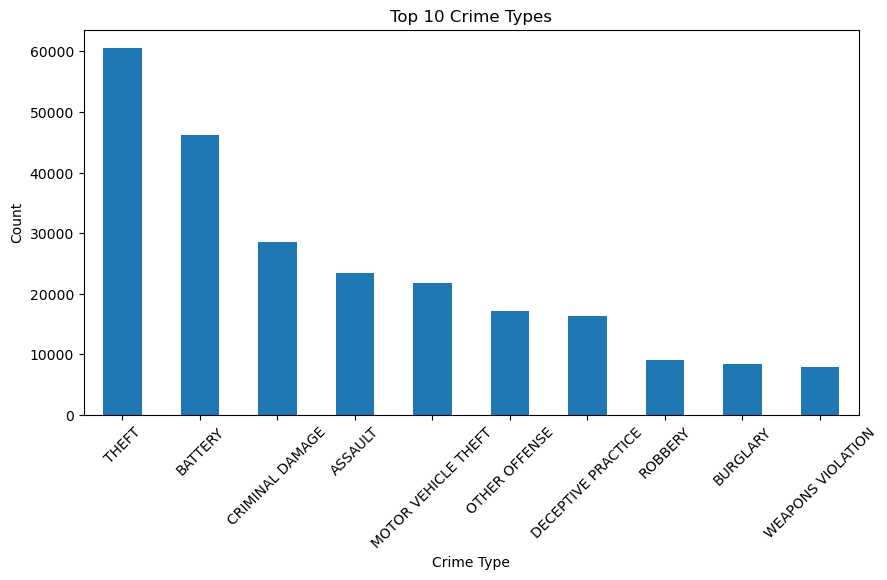

In [13]:
crime_df['Primary Type'].value_counts().head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Insight

The most common crime in Chicago is **THEFT**, followed by **BATTERY** and **CRIMINAL DAMAGE**. This shows that property-related and personal crimes occur most frequently.

In [17]:
crime_df['Date'] = pd.to_datetime(crime_df['Date'])

/var/folders/9s/f64mf5h91k7_zhfz27k5_c600000gn/T/ipykernel_25385/1137449007.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df['Date'] = pd.to_datetime(crime_df['Date'])


In [18]:
crime_df['Hour'] = crime_df['Date'].dt.hour

In [19]:
crime_df['Hour'].value_counts().sort_index()

Hour
0     17875
1      8643
2      7855
3      6696
4      5555
5      4759
6      4931
7      6482
8      8961
9     10640
10    11028
11    11328
12    14972
13    11689
14    12260
15    13928
16    13859
17    14009
18    13735
19    13391
20    12860
21    11956
22    11413
23    10212
Name: count, dtype: int64

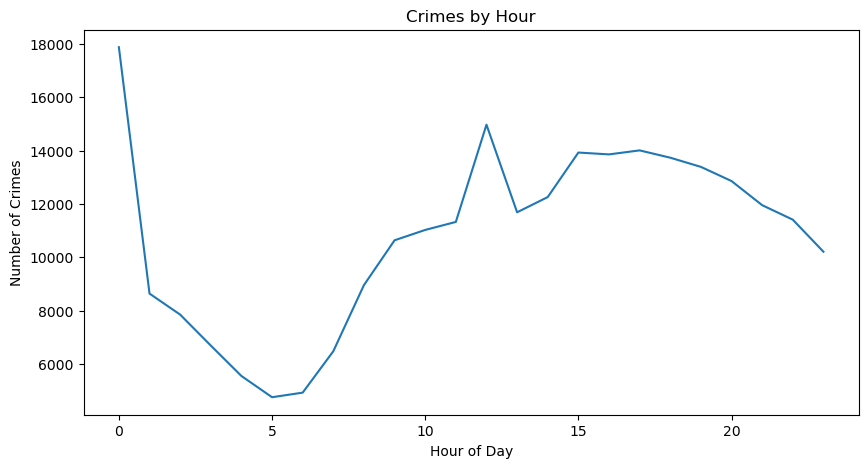

In [20]:
crime_df['Hour'].value_counts().sort_index().plot(kind='line', figsize=(10,5))

plt.title("Crimes by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.show()

### Insight

Crime is lowest in early morning hours (around 4–6 AM) and increases throughout the day, peaking in the afternoon and evening. This suggests higher activity when people are outside and active.

In [22]:
crime_df['Day of Week'] = crime_df['Date'].dt.day_name()

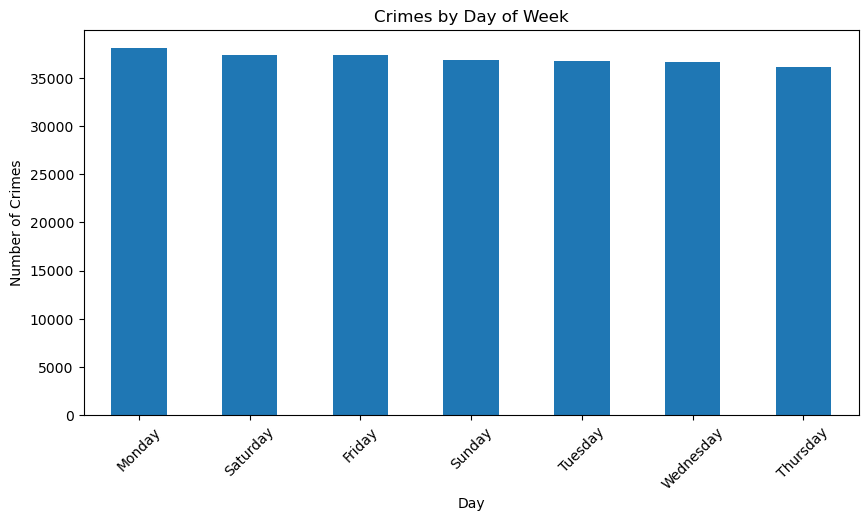

In [23]:
crime_df['Day of Week'].value_counts().plot(kind='bar', figsize=(10,5))

plt.title("Crimes by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.show()

### Insight

Crime is fairly consistent across all days of the week, with no extreme spikes. This suggests crime occurs regularly rather than being limited to specific days.